<a href="https://colab.research.google.com/github/ankit-kr6/LEARNING-ML/blob/main/video_37.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d rangalamahesh/house-prices-dataset

Dataset URL: https://www.kaggle.com/datasets/rangalamahesh/house-prices-dataset
License(s): apache-2.0
100% 184k/184k [00:00<00:00, 505kB/s]



In [2]:
import zipfile
with zipfile.ZipFile('house-prices-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [5]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [6]:
df.isnull().sum()*100

,0
FireplaceQu,69000
GarageQual,8100
SalePrice,0


<Axes: xlabel='GarageQual'>

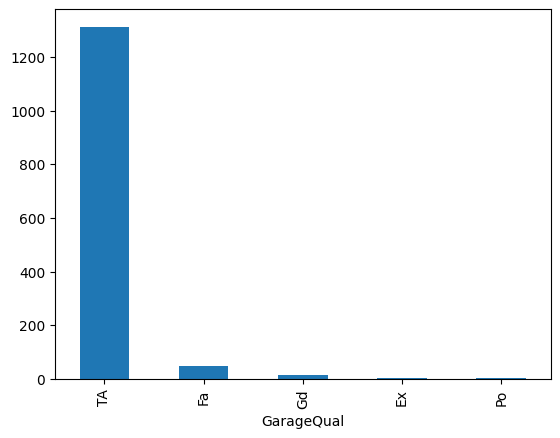

In [7]:
df['GarageQual'].value_counts().plot(kind='bar')

In [15]:
df['GarageQual'].mode()

,GarageQual
0,TA


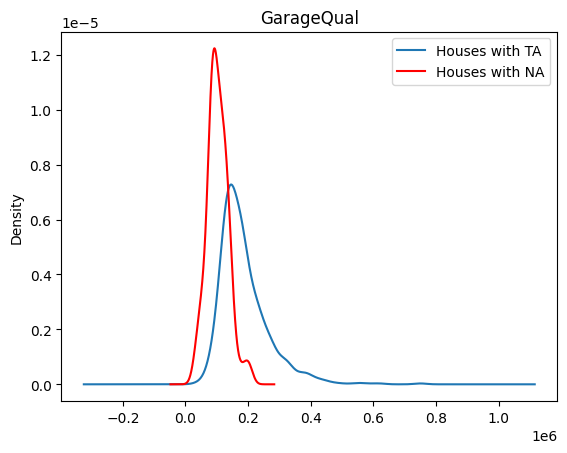

In [8]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Plot KDE for houses where GarageQual is 'TA'
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)

# Plot KDE for houses where GarageQual is null (NA)
df[df['GarageQual'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

# Set up the legend
lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with TA', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('GarageQual')
plt.show()

In [9]:
temp = df[df['GarageQual']=='TA']['SalePrice']

In [10]:
df['GarageQual'].fillna('TA',inplace=True)

/tmp/ipykernel_6946/2630493204.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['GarageQual'].fillna('TA',inplace=True)


<Axes: xlabel='GarageQual'>

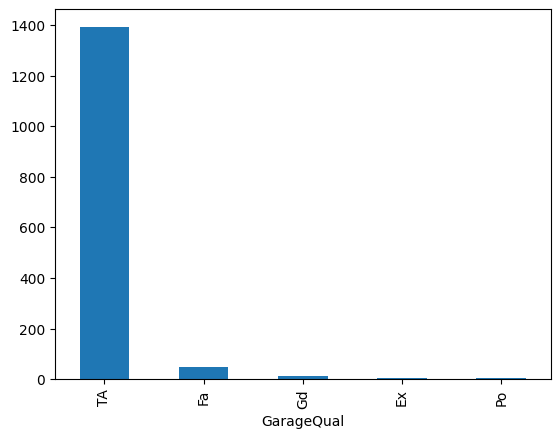

In [11]:
df['GarageQual'].value_counts().plot(kind='bar')

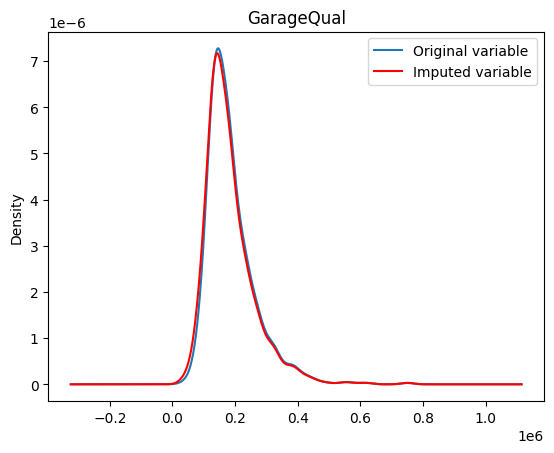

In [12]:
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111)

# Plot original distribution
temp.plot(kind='kde', ax=ax)

# Distribution of the variable after imputation
df[df['GarageQual'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax, color='red')

# Setup legend
lines, labels = ax.get_legend_handles_labels()
labels = ['Original variable', 'Imputed variable']
ax.legend(lines, labels, loc='best')

# Add title
plt.title('GarageQual')
plt.show()


<Axes: xlabel='FireplaceQu'>

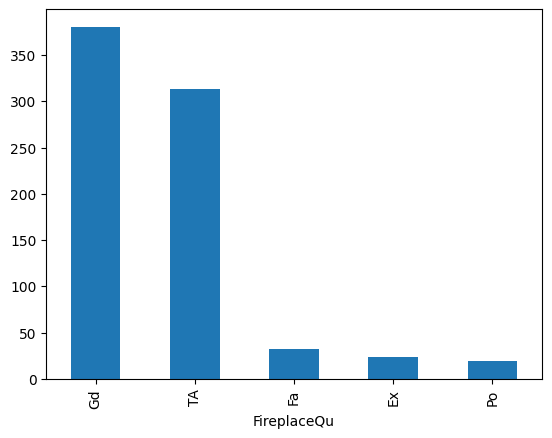

In [14]:
df['FireplaceQu'].value_counts().plot(kind='bar')

In [16]:
df['FireplaceQu'].mode()

,FireplaceQu
0,Gd


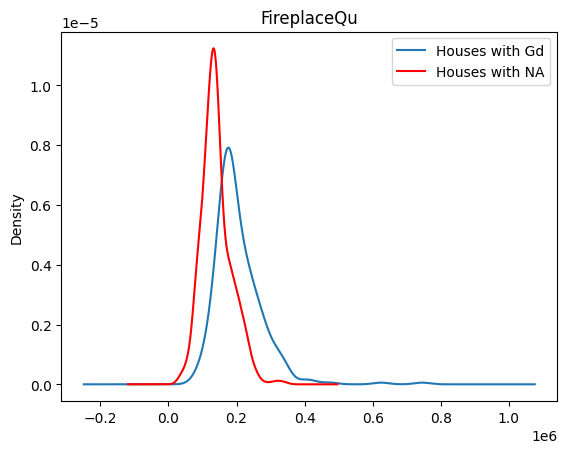

In [18]:
fig = plt.figure()
ax = fig.add_subplot(111)

# Plot KDE for houses where FireplaceQu
df[df['FireplaceQu'] == 'TA']['SalePrice'].plot(kind='kde', ax=ax)

# Plot KDE for houses where FireplaceQu
df[df['FireplaceQu'].isnull()]['SalePrice'].plot(kind='kde', ax=ax, color='red')

# Set up the legend
lines, labels = ax.get_legend_handles_labels()
labels = ['Houses with Gd', 'Houses with NA']
ax.legend(lines, labels, loc='best')

plt.title('FireplaceQu')
plt.show()

In [19]:
temp=df[df['FireplaceQu']=='Gd']['SalePrice']

In [20]:
df['FireplaceQu'].fillna('Gd',inplace=True)

/tmp/ipykernel_6946/891419280.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['FireplaceQu'].fillna('Gd',inplace=True)


<Axes: xlabel='FireplaceQu'>

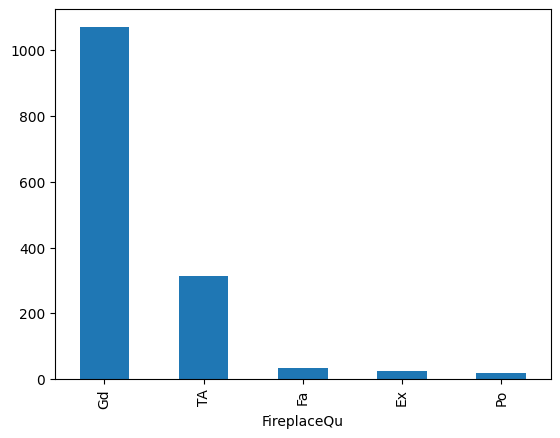

In [21]:
df['FireplaceQu'].value_counts().plot(kind='bar')

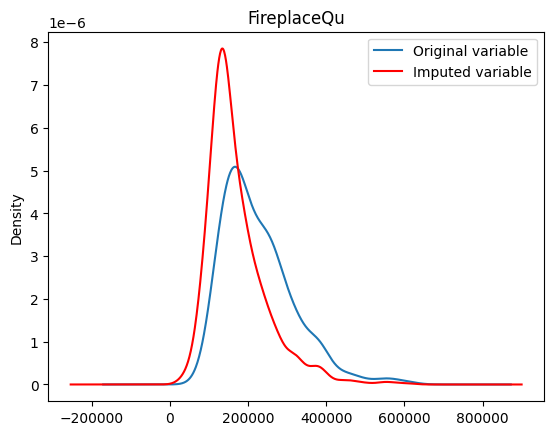

In [22]:
fig=plt.figure()
ax=fig.add_subplot(111)

temp.plot(kind='kde',ax=ax)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot(kind='kde',ax=ax,color='red')

lines,labels=ax.get_legend_handles_labels()
labels=['Original variable','Imputed variable']
ax.legend(lines,labels,loc='best')

plt.title('FireplaceQu')
plt.show()


In [23]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(labels=['SalePrice'],axis=1),df['SalePrice'],test_size=0.3,random_state=0)


In [24]:
from sklearn.impute import SimpleImputer


In [25]:
imputer=SimpleImputer(strategy='most_frequent')

In [26]:
x_train=imputer.fit_transform(x_train)
x_test=imputer.transform(x_test)

In [27]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)